Pertemuan 4
Nama    : Arsina
NIM     : 230401010199
Kelas : IF405

Langkah 1: Load & Inspect Dataset
Muat dataset Iris menggunakan seaborn.load_dataset(). Tampilkan shape, dtypes, head(), dan .describe().

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset Iris
df = sns.load_dataset('iris')

print('Shape')
print('Shape:', df.shape)

print('\n === Data Types ===')
print(df.dtypes)

print('\n === 5 Baris Pertama ===')
print(df.head())

print('\n === Statistik Deskriptif ===')
print(df.describe().round(3))

Shape
Shape: (150, 5)

 === Data Types ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

 === 5 Baris Pertama ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

 === Statistik Deskriptif ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800   

Langkah 2: Statistik Deskriptif Lengkap
Hitung mean, median, std, varians, skewness, kurtosis untuk setiap kolom numerik.

In [3]:
print('  STATISTIK DESKRIPTIF LENGKAP PER KOLOM NUMERIK')
print('=================================================')

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Varians  : {col.var():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')

     

  STATISTIK DESKRIPTIF LENGKAP PER KOLOM NUMERIK

=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Varians  : 0.686
  Skewness : 0.315
  Kurtosis : -0.552

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Varians  : 0.190
  Skewness : 0.319
  Kurtosis : 0.228

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Varians  : 3.116
  Skewness : -0.275
  Kurtosis : -1.402

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Varians  : 0.581
  Skewness : -0.103
  Kurtosis : -1.341


Langkah 3: Analisis Distribusi (Histogram + KDE)
Buat histogram + KDE untuk sepal_length. Tambahkan garis mean dan median. Identifikasi jenis distribusinya.

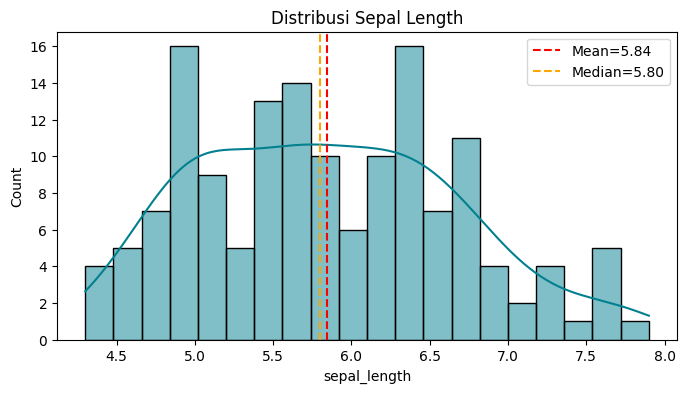

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
          linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
          linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()


Berdasarkan histogram dan kurva KDE, dapat disimpulkan bahwa:

Nilai mean dan median sepal_length sangat berdekatan, menunjukkan distribusi yang cukup simetris.
Skewness mendekati 0 mengkonfirmasi distribusi mendekati normal.
Dari plot per spesies, terlihat bahwa tiap spesies memiliki rentang sepal_length yang berbeda, dengan setosa cenderung lebih pendek dan virginica lebih panjang.

Langkah 4: Boxplot per Spesies
Buat boxplot petal_length per spesies. Identifikasi spesies dengan nilai terbesar, terkecil, dan paling tersebar

/tmp/ipykernel_6262/3351771149.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',
/tmp/ipykernel_6262/3351771149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',


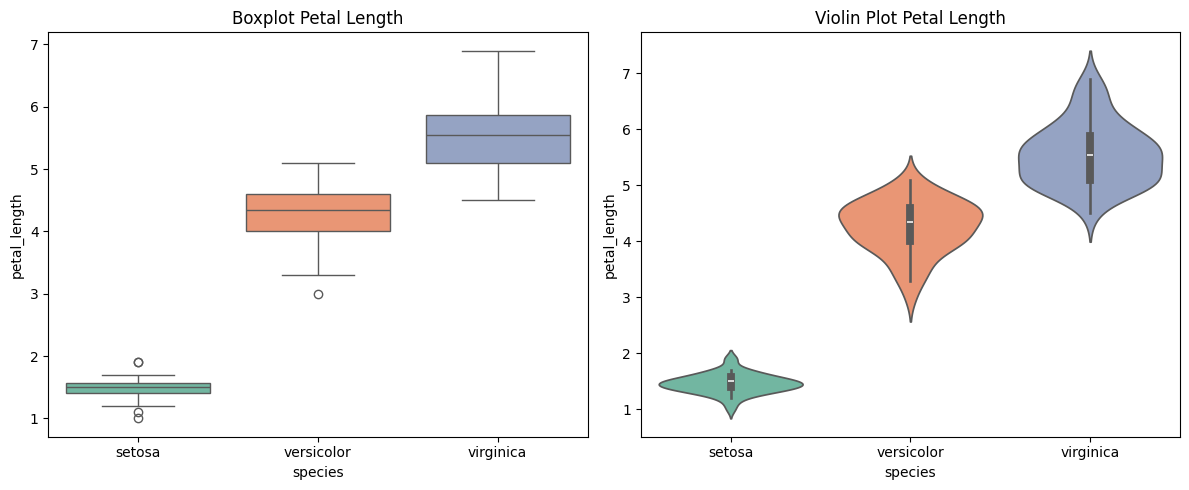

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
           palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',
           palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()

Dari data diatas, dapat disimpulkan bahwa:

Iris setosa memiliki petal_length paling kecil dan persebaran paling sempit (std rendah).

Iris virginica memiliki petal_length paling besar.

Iris versicolor berada di antara keduanya dengan persebaran yang cukup besar.

Violin plot mengonfirmasi bahwa distribusi setosa sangat terkonsentrasi, sementara virginica dan versicolor lebih tersebar.

Langkah 5: Matriks Korelasi Pearson
Hitung matriks korelasi. Identifikasi pasangan kolom dengan korelasi tertinggi dan terendah.

In [6]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Dari data di atas, dapat disimpulkan bahwa:

Pasangan petal_length ↔ petal_width memiliki korelasi tertinggi (sangat kuat positif), artinya bunga dengan mahkota panjang cenderung juga memiliki mahkota yang lebar.
sepal_width memiliki korelasi terendah (negatif) dengan kolom lain, menunjukkan hubungan yang sangat lemah bahkan berlawanan arah.

Langkah 6: Scatter Plot & Heatmap
Buat scatter plot pasangan paling berkorelasi + heatmap lengkap. Sertakan narasi interpretasi dalam Markdown.

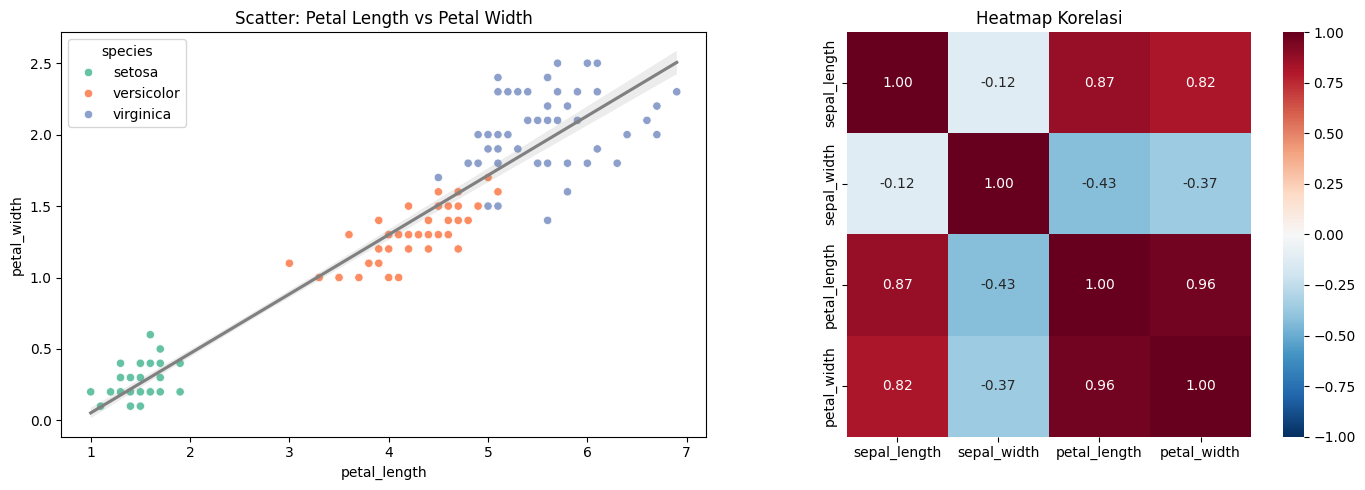

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
           scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
          vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()

Disimpulkan bahwa:

Scatter Plot:

Terlihat tren positif yang kuat antara petal_length dan petal_width: semakin panjang mahkota bunga, semakin lebar pula mahkotanya.
Garis regresi menegaskan hubungan linear yang konsisten pada ketiga spesies.
Spesies setosa (nilai kecil) terkluster terpisah dari versicolor dan virginica.
Heatmap Korelasi:

Warna merah gelap pada petal_length ↔ petal_width dan petal_length ↔ sepal_length menunjukkan korelasi positif kuat.
sepal_width tampak biru (korelasi negatif lemah) terhadap variabel petal, menunjukkan hubungan yang berlawanan arah namun tidak kuat.